In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,precision_score,accuracy_score,recall_score,f1_score
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [5]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [6]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [7]:
#Hanle Missing Value

categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['number']).columns

In [8]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [9]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [10]:
#using SimpleImputers for fill the Na values - numaric 'maen'
num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] =num_imp.fit_transform(df[numerical_cols])

In [11]:
#using SimpleImputers for fill the Na values - catgoric 'mode'
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [12]:
df.head()



,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [13]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [14]:
#EDA
#aw balanced our classes are?

classes_count = df['Loan_Approved'].value_counts()


Text(0.5, 1.0, 'Loan Approved or Not')

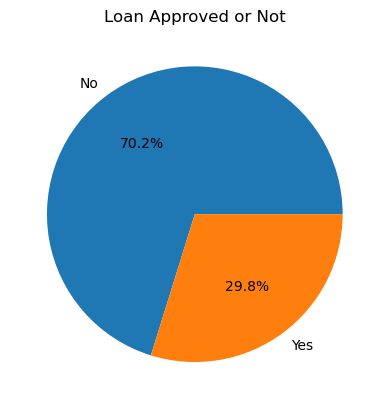

In [15]:
plt.pie(classes_count, labels=['No', 'Yes'], autopct ='%1.1f%%')
plt.title("Loan Approved or Not")

[Text(0, 0, '643'), Text(0, 0, '357')]

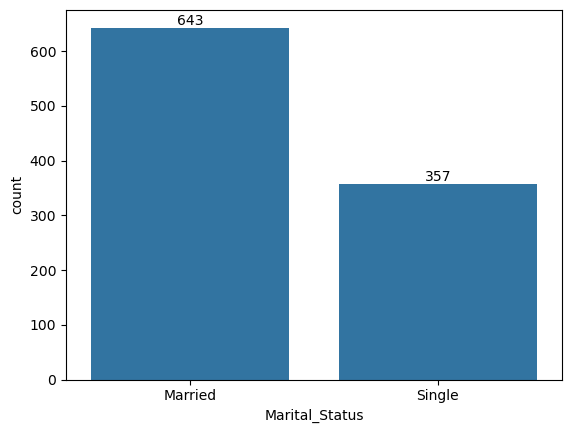

In [16]:
# analyze cateroies

# gender_count  = df["Gender"].value_counts()
# ax = sns.barplot(gender_count)
# ax.bar_label(ax.containers[0])

# edu_count =  df["Education_Level"].value_counts()
# ax = sns.barplot(edu_count)
# ax.bar_label(ax.containers[0])

married_count =  df["Marital_Status"].value_counts()
ax = sns.barplot(married_count)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

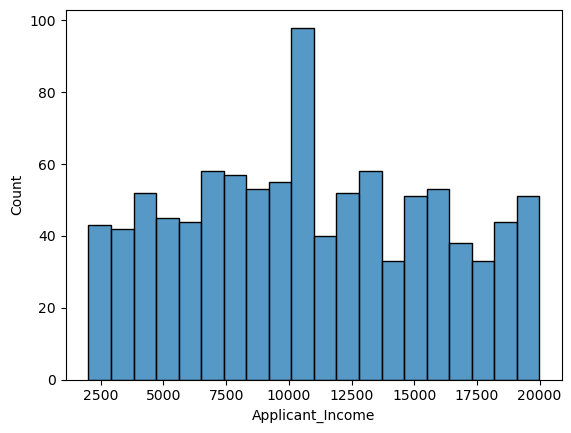

In [17]:
# analyze income

sns.histplot(
    data = df,
    x = 'Applicant_Income',
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

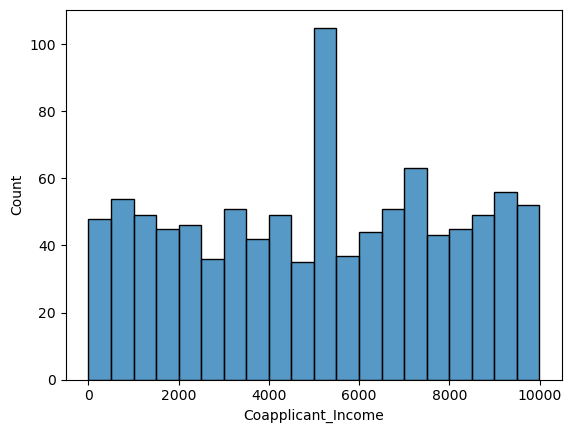

In [18]:
sns.histplot(
    data = df,
    x = 'Coapplicant_Income',
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

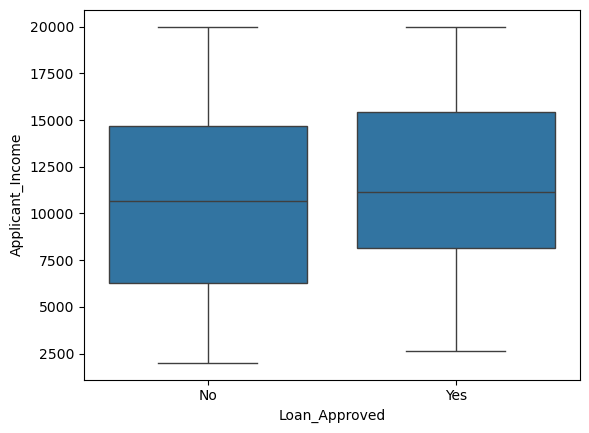

In [19]:
# uotliers - box plot

sns.boxplot(
    data = df,
    x = 'Loan_Approved',
    y = 'Applicant_Income'
)

<Axes: xlabel='Loan_Approved', ylabel='Savings'>

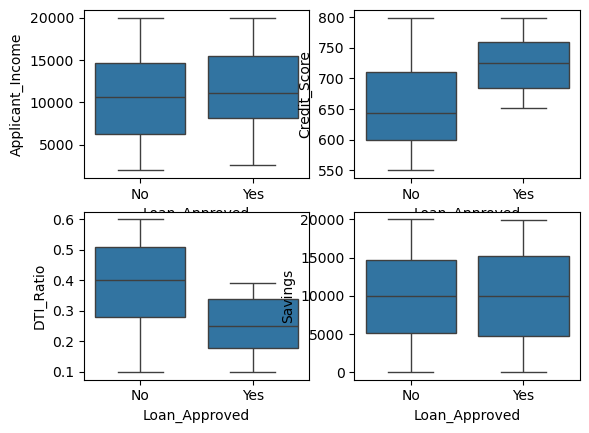

In [20]:
fig, axes = plt.subplots(2,2)

sns.boxplot(ax =axes[0, 0], data = df, x = 'Loan_Approved',y = 'Applicant_Income')
sns.boxplot(ax =axes[0, 1], data = df, x = 'Loan_Approved',y = 'Credit_Score')
sns.boxplot(ax =axes[1, 0], data = df, x = 'Loan_Approved',y = 'DTI_Ratio')
sns.boxplot(ax =axes[1, 1], data = df, x = 'Loan_Approved',y = 'Savings')

<Axes: xlabel='Credit_Score', ylabel='Count'>

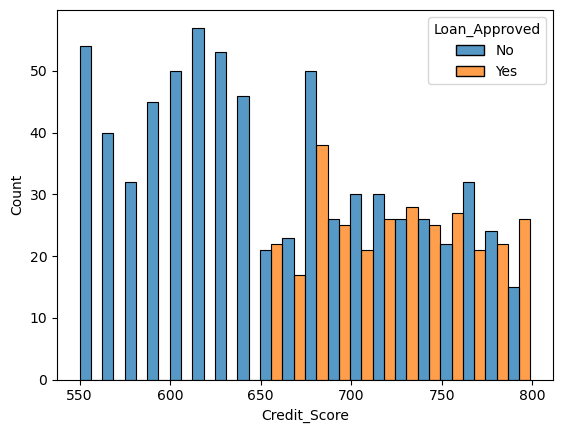

In [21]:
# Credit Score with Loan Approvel

sns.histplot(
    data = df,
    x = 'Credit_Score',
    hue = 'Loan_Approved',
    bins = 20,
    multiple="dodge"
)

In [22]:
#remove Applicant Id
df = df.drop("Applicant_ID",axis=1)

In [23]:
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [24]:
#Encoding

df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [25]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le = LabelEncoder()
df['Education_Level'] = le.fit_transform(df['Education_Level'])
df['Loan_Approved'] = le.fit_transform(df['Loan_Approved'])



In [26]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [27]:
cols = ['Employment_Status','Marital_Status','Loan_Purpose','Property_Area','Employer_Category','Gender']

ohe = OneHotEncoder(drop ='first', sparse_output = False, handle_unknown='ignore')

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [28]:
df

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Gender_Male
0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
996,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
997,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
998,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


<Axes: >

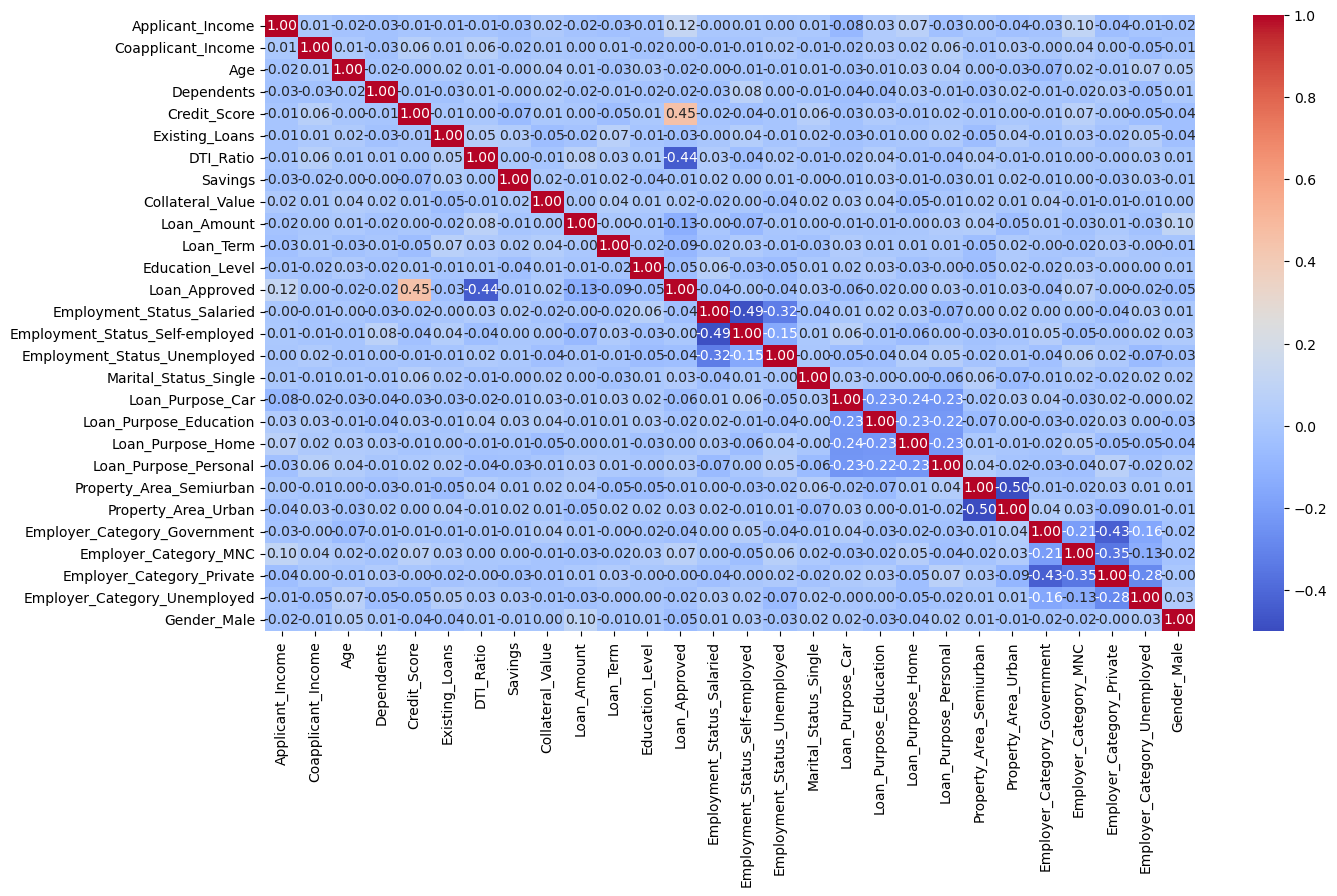

In [29]:
#Corrilation Heatmap

num_cols = df.select_dtypes(include='number')
corr_matrix = num_cols.corr()
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt = '.2f',
    cmap = 'coolwarm'
)

In [37]:
num_cols.corr()['Loan_Approved'].sort_values(ascending= False)

df.reset_index

<bound method DataFrame.reset_index of      Applicant_Income  Coapplicant_Income   Age  Dependents  Credit_Score  \
0        17795.000000              1387.0  51.0         0.0         637.0   
1         2860.000000              2679.0  46.0         3.0         621.0   
2         7390.000000              2106.0  25.0         2.0         674.0   
3        13964.000000              8173.0  40.0         2.0         579.0   
4        13284.000000              4223.0  31.0         2.0         721.0   
..                ...                 ...   ...         ...           ...   
995      10852.571579              9092.0  58.0         0.0         557.0   
996       3279.000000              6356.0  58.0         1.0         646.0   
997      15192.000000              8433.0  48.0         1.0         666.0   
998       9083.000000              7380.0  50.0         1.0         748.0   
999      13093.000000              2385.0  23.0         1.0         613.0   

     Existing_Loans  DTI_Ratio      

In [38]:
#Train-Test-Split

X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

In [45]:
X.head()
X.shape
y.shape

(1000,)

In [40]:
X_train,X_test,y_train,y_test = train_test_split(
    X, y ,test_size=0.2, random_state=42
)

In [41]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Gender_Male
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [74]:
#Train &  Evaluate Models

#For loogistic regression model
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()

log_model.fit(X_train_scaled,y_train)
y_pred = log_model.predict(X_test_scaled)
print("For Logistic Regression Model")
print('Recall score ',recall_score(y_test, y_pred))
print('F1 score ',f1_score(y_test, y_pred))
print("Prescision score", precision_score(y_test , y_pred))
print("accuracy score", accuracy_score(y_test , y_pred))

For Logistic Regression Model
Recall score  0.7704918032786885
F1 score  0.7768595041322314
Prescision score 0.7833333333333333
accuracy score 0.865


In [90]:
#For Knn model
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=13)

knn_model.fit(X_train_scaled,y_train)
y_pred = knn_model.predict(X_test_scaled)
print("For knn Regression Model")
print('Recall score ',recall_score(y_test, y_pred))
print('F1 score ',f1_score(y_test, y_pred))
print("Prescision score", precision_score(y_test , y_pred))
print("accuracy score", accuracy_score(y_test , y_pred))

For knn Regression Model
Recall score  0.4918032786885246
F1 score  0.5882352941176471
Prescision score 0.7317073170731707
accuracy score 0.79


In [92]:
#For naive based model
from sklearn.naive_bayes import GaussianNB
gaussian_model = GaussianNB()

gaussian_model.fit(X_train_scaled,y_train)
y_pred = gaussian_model.predict(X_test_scaled)
print("For Naive Bayes Regression Model")
print('Recall score ',recall_score(y_test, y_pred))
print('F1 score ',f1_score(y_test, y_pred))
print("Prescision score", precision_score(y_test , y_pred))
print("accuracy score", accuracy_score(y_test , y_pred))

For Naive Bayes Regression Model
Recall score  0.7377049180327869
F1 score  0.7692307692307693
Prescision score 0.8035714285714286
accuracy score 0.865


In [109]:
#Feature engineering

#ADD or Transform feture
df['DTI_Ratio'] =df['DTI_Ratio'] **2
df['Credit_Score'] =df['Credit_Score'] **2

# df['Applicant_Income_log'] = np.log1p(df['Applicant_Income'])

X = df.drop(columns=['Loan_Approved', 'Credit_Score','DTI_Ratio'])
y = df['Loan_Approved']

#Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
    X, y ,test_size=0.2, random_state=42
)

#Feture Scalling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [110]:
#Train &  Evaluate Models

#For loogistic regression model
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()

log_model.fit(X_train_scaled,y_train)

y_pred = log_model.predict(X_test_scaled)

print("For Logistic Regression Model")
print('Recall score ',recall_score(y_test, y_pred))
print('F1 score ',f1_score(y_test, y_pred))
print("Prescision score", precision_score(y_test , y_pred))
print("accuracy score", accuracy_score(y_test , y_pred))

For Logistic Regression Model
Recall score  0.04918032786885246
F1 score  0.08571428571428572
Prescision score 0.3333333333333333
accuracy score 0.68


In [111]:
#For naive based model
from sklearn.naive_bayes import GaussianNB
gaussian_model = GaussianNB()

gaussian_model.fit(X_train_scaled,y_train)

y_pred = gaussian_model.predict(X_test_scaled)

print("For Naive Bayes Regression Model")
print('Recall score ',recall_score(y_test, y_pred))
print('F1 score ',f1_score(y_test, y_pred))
print("Prescision score", precision_score(y_test , y_pred))
print("accuracy score", accuracy_score(y_test , y_pred))

For Naive Bayes Regression Model
Recall score  0.26229508196721313
F1 score  0.3137254901960784
Prescision score 0.3902439024390244
accuracy score 0.65


In [112]:
#For Knn model
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=13)

knn_model.fit(X_train_scaled,y_train)
y_pred = knn_model.predict(X_test_scaled)
print("For knn Regression Model")
print('Recall score ',recall_score(y_test, y_pred))
print('F1 score ',f1_score(y_test, y_pred))
print("Prescision score", precision_score(y_test , y_pred))
print("accuracy score", accuracy_score(y_test , y_pred))

For knn Regression Model
Recall score  0.14754098360655737
F1 score  0.23376623376623376
Prescision score 0.5625
accuracy score 0.705
